In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

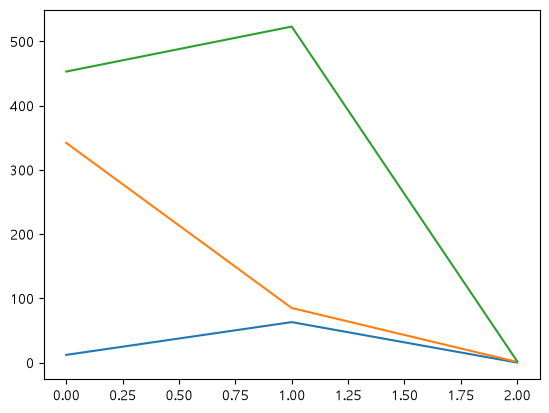

In [11]:
arr = np.array([
        [12,342,453],
        [63,85,523],
        [0,1,2]
    ])

plt.plot(arr)


In [12]:
plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "지점": [
        "강남", "강남", "강남", "홍대", "홍대",
        "홍대", "종로", "종로", "종로", "종로"
    ],
    "메뉴": [
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크", "아메리카노"
    ],
    "가격": [
        4500, 5500, 7000,
        4500, 5500, 7000,
        4500, 5500, 7000, 4500
    ],
    "판매량": [
        120, 80, 30,
        150, 60, 45,
        90, 100, 25, 110
    ],
    "평점": [
        4.5, 4.2, 4.8,
        4.7, 3.9, 4.6,
        4.1, np.nan, 4.9, 4.3
    ]
}

df = pd.DataFrame(data)
# df의 행/열 개수, 컬럼 이름, 각 컬럼의 자료형을 확인하세요.

# 처음 5개의 데이터만 출력하세요.

# "메뉴" 컬럼만 Series 형태로 가져오고, 실제로 Series 타입인지 확인하세요.

# "지점", "메뉴", "판매량" 세 컬럼만 가져오세요.

# 판매량이 100 이상인 데이터만 추출하세요.

# 판매량이 100 이상이면서 메뉴가 아메리카노인 데이터만 추출하세요.

# "매출"이라는 새로운 컬럼을 만드세요.

# 매출이 가장 높은 행을 찾아서 지점, 메뉴, 매출을 출력하세요. 지금 배운 max()나 argmax()/idxmax() 등을 생각해보세요.

# groupby()를 이용해서 지점별 총 매출을 구하세요.

# groupby()를 이용해서 메뉴별 평균 판매량을 구하세요.

# 지점별로 데이터가 몇 개씩 있는지 구하세요.

# "평점"에 결측값(NaN)이 몇 개 있는지 확인하세요.

# apply()와 함수를 이용해서 "평가"라는 파생변수를 만드세요.
# 전체 판매량의 평균, 편차, 편차의 제곱, 분산, 표준편차를 직접 구해보세요. 처음부터 std()를 쓰지 말고 지금 배운 방식으로 계산합니다.
# 마지막으로 그래프를 3개 그려보세요. 지점별 총 매출은 막대그래프, 판매량은 히스토그램, 가격과 판매량의 관계는 산점도로 표현하세요.

In [38]:
# df의 행/열 개수, 컬럼 이름, 각 컬럼의 자료형을 확인하세요.

print(df.shape)
print(list(df.columns))

for i in df.columns:
    print(f"{i} 컬럼의 타입 : {df[i].dtype}")



df.dtypes

(10, 5)
['지점', '메뉴', '가격', '판매량', '평점']
지점 컬럼의 타입 : str
메뉴 컬럼의 타입 : str
가격 컬럼의 타입 : int64
판매량 컬럼의 타입 : int64
평점 컬럼의 타입 : float64


지점         str
메뉴         str
가격       int64
판매량      int64
평점     float64
dtype: object

In [39]:
# 처음 5개의 데이터만 출력하세요.

df.head()

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
1,강남,라떼,5500,80,4.2
2,강남,케이크,7000,30,4.8
3,홍대,아메리카노,4500,150,4.7
4,홍대,라떼,5500,60,3.9


In [41]:
# "메뉴" 컬럼만 Series 형태로 가져오고, 실제로 Series 타입인지 확인하세요.

type(df["메뉴"])

pandas.Series

In [42]:
# "지점", "메뉴", "판매량" 세 컬럼만 가져오세요.
df[["지점","메뉴","판매량"]]

,지점,메뉴,판매량
0,강남,아메리카노,120
1,강남,라떼,80
2,강남,케이크,30
3,홍대,아메리카노,150
4,홍대,라떼,60
5,홍대,케이크,45
6,종로,아메리카노,90
7,종로,라떼,100
8,종로,케이크,25
9,종로,아메리카노,110


In [47]:
# 판매량이 100 이상인 데이터만 추출하세요.

panmae_mask = df["판매량"] >= 100
df[panmae_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
7,종로,라떼,5500,100,NaN
9,종로,아메리카노,4500,110,4.3


In [50]:
# 판매량이 100 이상이면서 메뉴가 아메리카노인 데이터만 추출하세요.

sold_ame_mask = (df["판매량"] >= 100) & (df["메뉴"] == "아메리카노")
df[sold_ame_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
9,종로,아메리카노,4500,110,4.3


In [53]:
# "매출"이라는 새로운 컬럼을 만드세요.

df["매출"] = df["가격"] * df["판매량"]
df

,지점,메뉴,가격,판매량,평점,매출
0,강남,아메리카노,4500,120,4.5,540000
1,강남,라떼,5500,80,4.2,440000
2,강남,케이크,7000,30,4.8,210000
3,홍대,아메리카노,4500,150,4.7,675000
4,홍대,라떼,5500,60,3.9,330000
5,홍대,케이크,7000,45,4.6,315000
6,종로,아메리카노,4500,90,4.1,405000
7,종로,라떼,5500,100,NaN,550000
8,종로,케이크,7000,25,4.9,175000
9,종로,아메리카노,4500,110,4.3,495000


In [68]:
# 매출이 가장 높은 행을 찾아서 지점, 메뉴, 매출을 출력하세요. 지금 배운 max()나 argmax()/idxmax() 등을 생각해보세요.
df.iloc[df["매출"].argmax()]

지점         홍대
메뉴      아메리카노
가격       4500
판매량       150
평점        4.7
매출     675000
Name: 3, dtype: object

In [70]:
amtn_mask = df["매출"] == max(df["매출"])

df[amtn_mask]

,지점,메뉴,가격,판매량,평점,매출
3,홍대,아메리카노,4500,150,4.7,675000


In [82]:
# groupby()를 이용해서 지점별 총 매출을 구하세요.
df.groupby("지점")["매출"].sum()

지점
강남    1190000
종로    1625000
홍대    1320000
Name: 매출, dtype: int64

In [85]:
# groupby()를 이용해서 메뉴별 평균 판매량을 구하세요.
round(df.groupby("메뉴")[["판매량"]].mean(),2)

,판매량
메뉴,
라떼,80.00
아메리카노,117.50
케이크,33.33


In [103]:
# 지점별로 데이터가 몇 개씩 있는지 구하세요.
# df.groupby("지점")["지점"].count()

df.groupby("지점").size()

지점
강남    3
종로    4
홍대    3
dtype: int64

In [123]:
# "평점"에 결측값(NaN)이 몇 개 있는지 확인하세요.
print(len(df[df["평점"].isna()]))

1


In [124]:
# apply()와 함수를 이용해서 "평가"라는 파생변수를 만드세요.
# 평점이 NaN → "평가 없음"
# 평점 >= 4.5 → "우수"
# 나머지 → "보통"

def is_peong(peong):
    if not peong == peong:
        return "평가 없음"
    return "우수" if peong >= 4.5 else "보통"


df["평가"] = df["평점"].apply(is_peong)

df

,지점,메뉴,가격,판매량,평점,매출,평가
0,강남,아메리카노,4500,120,4.5,540000,우수
1,강남,라떼,5500,80,4.2,440000,보통
2,강남,케이크,7000,30,4.8,210000,우수
3,홍대,아메리카노,4500,150,4.7,675000,우수
4,홍대,라떼,5500,60,3.9,330000,보통
5,홍대,케이크,7000,45,4.6,315000,우수
6,종로,아메리카노,4500,90,4.1,405000,보통
7,종로,라떼,5500,100,NaN,550000,평가 없음
8,종로,케이크,7000,25,4.9,175000,우수
9,종로,아메리카노,4500,110,4.3,495000,보통


In [138]:
# 전체 판매량의 평균, 편차, 편차의 제곱, 분산, 표준편차를 직접 구해보세요. 처음부터 std()를 쓰지 말고 지금 배운 방식으로 계산합니다.

import math

print(df["판매량"].mean())

print(df["판매량"] - df["판매량"].mean())

print((df["판매량"] - df["판매량"].mean())**2)

print(((df["판매량"] - df["판매량"].mean())**2).mean())

print(((df["판매량"] - df["판매량"].mean())**2).mean()**0.5)
print(np.sqrt(((df["판매량"] - df["판매량"].mean())**2).mean()))

81.0
0    39.0
1    -1.0
2   -51.0
3    69.0
4   -21.0
5   -36.0
6     9.0
7    19.0
8   -56.0
9    29.0
Name: 판매량, dtype: float64
0    1521.0
1       1.0
2    2601.0
3    4761.0
4     441.0
5    1296.0
6      81.0
7     361.0
8    3136.0
9     841.0
Name: 판매량, dtype: float64
1504.0
38.781438859330635
38.781438859330635


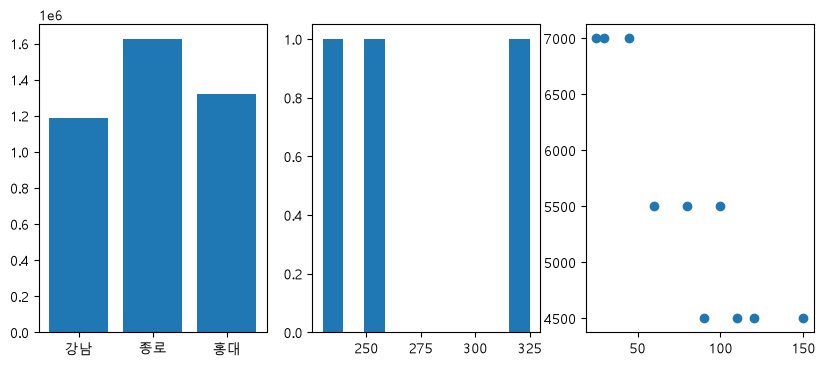

In [176]:
# 마지막으로 그래프를 3개 그려보세요. 지점별 총 매출은 막대그래프, 판매량은 히스토그램, 가격과 판매량의 관계는 산점도로 표현하세요.

fig = plt.figure(figsize=(10,4))

ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.bar(df.groupby("지점").size().index,df.groupby("지점")["매출"].sum())
ax2.hist(df.groupby("지점")["판매량"].sum())
ax3.scatter(df["판매량"],df["가격"])

In [157]:
df.groupby("지점").size().index

Index(['강남', '종로', '홍대'], dtype='str', name='지점')

In [159]:
df.groupby("지점")["매출"].sum()

지점
강남    1190000
종로    1625000
홍대    1320000
Name: 매출, dtype: int64

In [161]:
df.groupby("메뉴")[["판매량"]].sum()

,판매량
메뉴,
라떼,240
아메리카노,470
케이크,100


In [166]:
ax2.hist(df.groupby("메뉴")["판매량"].sum())

(array([1., 0., 0., 1., 0., 0., 0., 0., 0., 1.]),
 array([100., 137., 174., 211., 248., 285., 322., 359., 396., 433., 470.]),
 <BarContainer object of 10 artists>)

In [172]:
df.groupby("지점")["판매량"].sum()

지점
강남    230
종로    325
홍대    255
Name: 판매량, dtype: int64

In [187]:
# 각 지점에서 매출이 가장 높은 메뉴를 하나씩 찾아 출력하세요.
# 원하는 결과의 형태는 대략:
# 강남    ???
# 홍대    ???
# 종로    ???


df.groupby("메뉴")["매출"].sum()

'아메리카노'

In [194]:
df.groupby("지점")["메뉴"].idxmax("매출")

지점
강남    2
종로    8
홍대    5
Name: 메뉴, dtype: int64